In [ ]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

In [2]:
df1 = pd.read_csv("../dataset/train.csv")
df2 = pd.read_csv("../dataset/test.csv")
X_train = df1.drop(columns = ['Churn'])
y_train = df1['Churn'].values
X_test = df2.drop(columns = ['Churn'])
y_test = df2['Churn'].values

In [3]:
#build model
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
#for binary output like this project
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [4]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
y_train = y_train.astype("int32")
y_test = y_test.astype("int32")
#train
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)

#test
y_pred = (model.predict(X_test) > 0.5).astype("int32")

Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7468 - loss: 0.5417 - val_accuracy: 0.7861 - val_loss: 0.4776
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7660 - loss: 0.4972 - val_accuracy: 0.7839 - val_loss: 0.4665
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7737 - loss: 0.4799 - val_accuracy: 0.7804 - val_loss: 0.4566
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7783 - loss: 0.4778 - val_accuracy: 0.7910 - val_loss: 0.4380
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7705 - loss: 0.4806 - val_accuracy: 0.7960 - val_loss: 0.4484
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7776 - loss: 0.4714 - val_accuracy: 0.7974 - val_loss: 0.4454
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7746 - loss: 0.4710 - val_accuracy: 0.7974 - val_loss: 0.4299
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7822 - loss: 0.4655 - val_accuracy: 0.

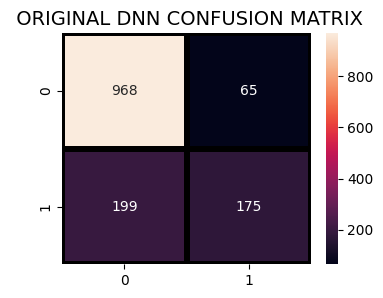

In [5]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title(" ORIGINAL DNN CONFUSION MATRIX",fontsize=14)
plt.show()

In [6]:
#adding class weight
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))
print(class_weights_dict)

history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, class_weight=class_weights_dict, verbose=1)
y_pred_weight = (model.predict(X_test) > 0.5).astype("int32")

{0: np.float64(0.6809927360774818), 1: np.float64(1.8812709030100334)}
Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7623 - loss: 0.5426 - val_accuracy: 0.7008 - val_loss: 0.5345
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7428 - loss: 0.5285 - val_accuracy: 0.7484 - val_loss: 0.4858
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7401 - loss: 0.5158 - val_accuracy: 0.7285 - val_loss: 0.4926
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7435 - loss: 0.5246 - val_accuracy: 0.7484 - val_loss: 0.4799
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7333 - loss: 0.5327 - val_accuracy: 0.7903 - val_loss: 0.4280
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7294 - loss: 0.5301 - val_accuracy: 0.7811 - val_loss: 0.4608
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7417 - loss: 0.5255 - val_accuracy: 0.7925 - val_loss: 0.4374
Epoch 8/50
176/176 ━━━━━━━━━━━━━━

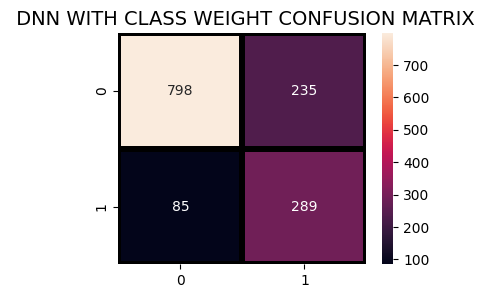

In [7]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_weight), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title(" DNN WITH CLASS WEIGHT CONFUSION MATRIX",fontsize=14)
plt.show()

In [8]:
#model's structure manipulation (increasing hidden layers, adding dropout and batch normalization)
#Input layer
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.4))
#Hidden layers: increasing hidden layers, adding dropout 3-4
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.3))
#Output layer
model.add(Dense(1, activation='sigmoid'))
#Compile
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

#train
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32, verbose=1)

Epoch 1/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7205 - loss: 0.5384 - val_accuracy: 0.7342 - val_loss: 0.5581
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7659 - loss: 0.4880 - val_accuracy: 0.7342 - val_loss: 0.5279
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7769 - loss: 0.4800 - val_accuracy: 0.7477 - val_loss: 0.4548
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7778 - loss: 0.4833 - val_accuracy: 0.7754 - val_loss: 0.4364
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7877 - loss: 0.4598 - val_accuracy: 0.7896 - val_loss: 0.4753
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7808 - loss: 0.4647 - val_accuracy: 0.8053 - val_loss: 0.4126
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7737 - loss: 0.4731 - val_accuracy: 0.8060 - val_loss: 0.4184
Epoch 8/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7897 - loss: 0.4620 - val_accu

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


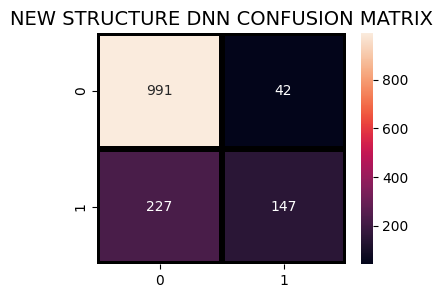

In [9]:
#test
y_pred_struc = (model.predict(X_test) > 0.5).astype("int32")

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_struc), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title("NEW STRUCTURE DNN CONFUSION MATRIX",fontsize=14)
plt.show()

In [10]:
#threshold tuning
y_pred_proba = model.predict(X_test)
best_f1 = 0
best_threshold = 0.5
#trying consecutively from 0.2 to 0.8
for t in [i/100 for i in range(20, 81, 5)]:
    y_pred = (y_pred_proba > t).astype("int32")
    f1 = f1_score(y_test, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t
print("Best threshold:", best_threshold, "with F1:", best_f1)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 769us/step
Best threshold: 0.35 with F1: 0.650887573964497


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step


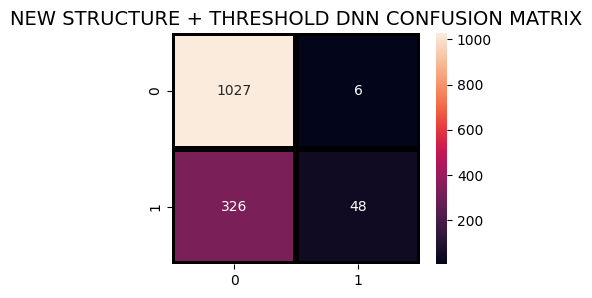

In [12]:
#apply threshold above
y_pred_proba = model.predict(X_test)
best_threshold = 0.650887573964497
y_pred_opt = (y_pred_proba > best_threshold).astype("int32")

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_opt), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title("NEW STRUCTURE + THRESHOLD DNN CONFUSION MATRIX",fontsize=14)
plt.show()

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 754us/step


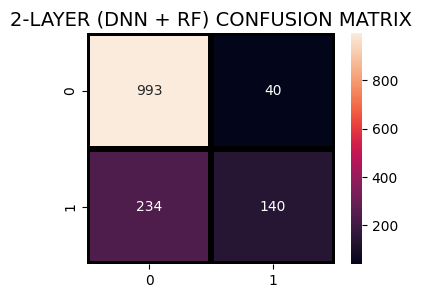

In [13]:
#take dnn (adjusted structure) as layer 1
y_pred_proba_dnn = model.predict(X_test)
y_pred_dnn = (y_pred_proba_dnn > 0.5).astype("int32")

#filter out customers that tagged as churn
churn_candidates = X_test[y_pred_dnn.flatten() == 1]

#layer 2 = RF (100 trees, depth 10)
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(churn_candidates).flatten()

#the final result will only keep customers verified by RF
final_predictions = y_pred_dnn.copy()
final_predictions[y_pred_dnn == 1] = y_pred_rf

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, final_predictions), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title("2-LAYER (DNN + RF) CONFUSION MATRIX",fontsize=14)
plt.show()